In [1]:
# To start my project, I will have to load the data. This will be done in the next cell using pandas to load the data from the csv files.
# I will also merge the dataframes together to create a single dataset that contains all the necessary information for my analysis.
# In this project we will make a popularity filter, to view the most popular films, then also create an hybrid collaborative
# filtering system to recommend movies based on the movies a user has rated highly that stays within the same genre. 
# Basically the "other users who liked this movie also liked..." section of Netflix.

In [2]:
import pandas as pd

ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [3]:
data = ratings.merge(movies, on="movieId")

print(data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [4]:
# Method 1: Popularity Filter
# To find the average rating for each movie, we can use the groupby function and calculate the mean of each. We also calculate the number of ratings for each film.

In [5]:
average = data.groupby("title")["rating"].mean()

count = data.groupby("title")["rating"].count()

movie_stats = pd.DataFrame()

movie_stats["average_rating"] = average

movie_stats["rating_count"] = count

print(movie_stats.head())

                                         average_rating  rating_count
title                                                                
'71 (2014)                                          4.0             1
'Hellboy': The Seeds of Creation (2004)             4.0             1
'Round Midnight (1986)                              3.5             2
'Salem's Lot (2004)                                 5.0             1
'Til There Was You (1997)                           4.0             2


In [6]:
# After seeing a table printed with such a low rating count, I want to ensure my popularity filter has a good threshold, I will find the max rating count and mean
# in order to find a good threshold for the popularity filter.

In [7]:
max_rated_movie = movie_stats["rating_count"].idxmax() #I'm curious about what movie had the most ratings in this dataset :)
max_rating_count = movie_stats.loc[max_rated_movie, "rating_count"]
average_rating_count = movie_stats["rating_count"].mean()

print("Max rated movie:", max_rated_movie)
print("Max rating count:", max_rating_count)
print("Average rating:", average_rating_count)

Max rated movie: Forrest Gump (1994)
Max rating count: 329
Average rating: 10.375141475460438


In [8]:
#I see the average is still quite low, I'll sift through the data using arbitrary thresholds

In [9]:
thresholds = [5, 10, 25, 50, 100, 200]

for threshold in thresholds:
    
    filtered = movie_stats[movie_stats["rating_count"] >= threshold]
    
    print(f"Movies with at least {threshold} ratings: {len(filtered)}")

Movies with at least 5 ratings: 3651
Movies with at least 10 ratings: 2269
Movies with at least 25 ratings: 1050
Movies with at least 50 ratings: 450
Movies with at least 100 ratings: 138
Movies with at least 200 ratings: 19


In [10]:
# Based upon the thresholds above, I will choose a popularity filter of 100 ratings, due to this being a popularity filter, meaning, the movies have to be
# popular enough to have a high amount of ratings. Considering the most rated film has 342 ratings, the filter for popularity should ensure enough people have
# rated the movie.
# My next segment will be listing the top 10 movies based upon their rating, only including 100 ratings or more because it is a popularity contest.

In [11]:
threshold = 100
popular_movies = movie_stats[movie_stats["rating_count"] >= threshold]

top_movies = popular_movies.sort_values(
    by=["average_rating", "rating_count"],
    ascending=[False, False]
)

print(top_movies.head(10).reset_index())

                              title  average_rating  rating_count
0  Shawshank Redemption, The (1994)        4.429022           317
1             Godfather, The (1972)        4.289062           192
2                 Fight Club (1999)        4.272936           218
3    Godfather: Part II, The (1974)        4.259690           129
4              Departed, The (2006)        4.252336           107
5                 Goodfellas (1990)        4.250000           126
6                 Casablanca (1942)        4.240000           100
7           Dark Knight, The (2008)        4.238255           149
8        Usual Suspects, The (1995)        4.237745           204
9        Princess Bride, The (1987)        4.232394           142


In [12]:
# This list makes a lot of sense to me, due to the fact these films are all very popular and well known, and I believe are generally all on the American Film
# Institute's top 100 movies list, which is a list of the best American films of all time, and I have viewed these in cinema classes I've taken based upon
# American Cinema.

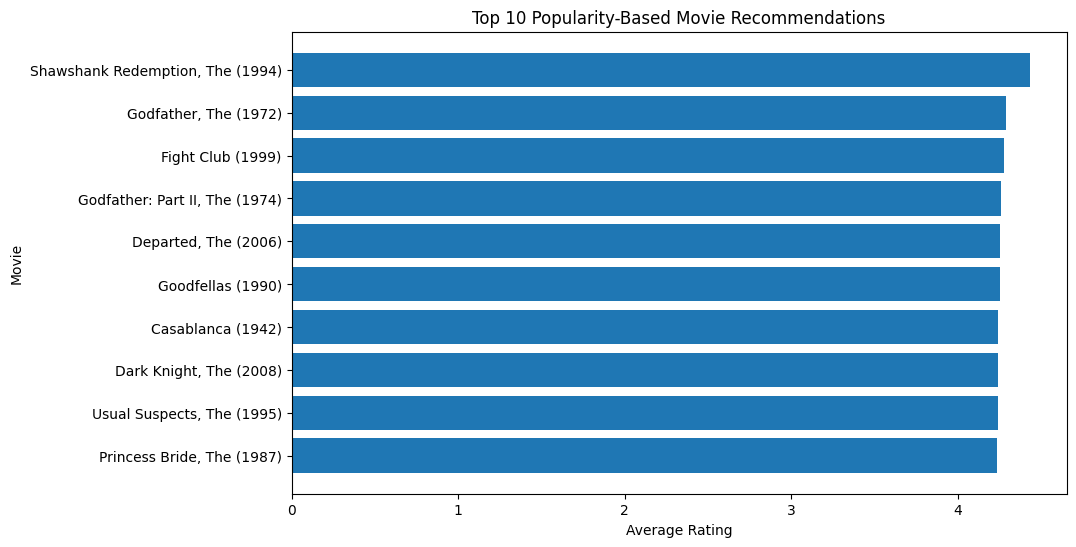

In [13]:
import matplotlib.pyplot as plt

top_10 = top_movies.head(10).reset_index()

plt.figure(figsize=(10, 6))
plt.barh(top_10["title"], top_10["average_rating"])
plt.xlabel("Average Rating")
plt.ylabel("Movie")
plt.title("Top 10 Popularity-Based Movie Recommendations")
plt.gca().invert_yaxis()
plt.show()

In [14]:
# To confirm my bias of having an 100 rating threshold, I will create a scatter plot that will show the relationship between the average rating and rating count.

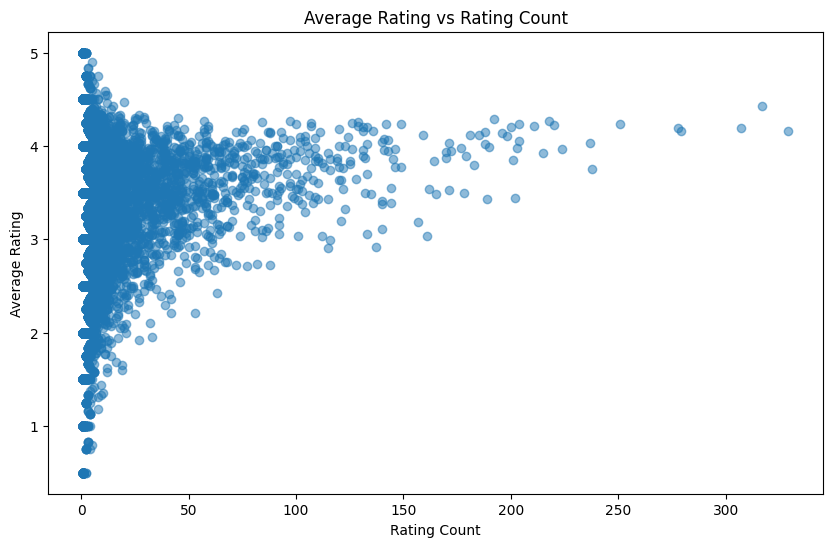

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    movie_stats["rating_count"],
    movie_stats["average_rating"],
    alpha=0.5
)

plt.xlabel("Rating Count")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Rating Count")

plt.show()

In [16]:
# Based on this scatter plot, I will say my choice of having 100 or more ratings was a good one, due to there still being a lot of data to work with, and
# that there are far too many low rating count movies that would've been included in the popularity filter if the threshold had been lower, therefore rendering
# the filter less effective because those movies weren't popular enough to be considered in the running for a popularity filter.
# Below I will end method 1 by displaying the number of movies that were included, and the basic stats of said movies.

In [17]:
print("Number of movies after filtering:", len(popular_movies))

print(top_movies.head(10).reset_index())

Number of movies after filtering: 138
                              title  average_rating  rating_count
0  Shawshank Redemption, The (1994)        4.429022           317
1             Godfather, The (1972)        4.289062           192
2                 Fight Club (1999)        4.272936           218
3    Godfather: Part II, The (1974)        4.259690           129
4              Departed, The (2006)        4.252336           107
5                 Goodfellas (1990)        4.250000           126
6                 Casablanca (1942)        4.240000           100
7           Dark Knight, The (2008)        4.238255           149
8        Usual Suspects, The (1995)        4.237745           204
9        Princess Bride, The (1987)        4.232394           142


In [18]:
# I am a big fan of the horror genre, which in general can be viewed as more niche, so before I continue, I just want to see what horror movies are in this dataset.

In [19]:
horror_movies = data[
    data["genres"].str.contains("Horror", na=False)
]
print(horror_movies.head())

    userId  movieId  rating  timestamp                             title  \
5        1       70     3.0  964982400        From Dusk Till Dawn (1996)   
34       1      593     4.0  964983793  Silence of the Lambs, The (1991)   
75       1     1214     4.0  964981855                      Alien (1979)   
76       1     1219     2.0  964983393                     Psycho (1960)   
83       1     1258     3.0  964983414               Shining, The (1980)   

                           genres  
5   Action|Comedy|Horror|Thriller  
34          Crime|Horror|Thriller  
75                  Horror|Sci-Fi  
76                   Crime|Horror  
83                         Horror  


In [20]:
horror_stats = horror_movies.groupby("title")["rating"].agg(["mean", "count"])

horror_stats.columns = ["average_rating", "rating_count"]

popular_horror = horror_stats[horror_stats["rating_count"] >= 50]

top_horror = popular_horror.sort_values(
    by="average_rating",
    ascending=False
)

print(top_horror.head(10).reset_index())

                              title  average_rating  rating_count
0  Silence of the Lambs, The (1991)        4.161290           279
1               Shining, The (1980)        4.082569           109
2           Army of Darkness (1993)        4.039216            51
3                     Psycho (1960)        4.036145            83
4          Shaun of the Dead (2004)        4.006494            77
5                       Jaws (1975)        4.005495            91
6              28 Days Later (2002)        3.974138            58
7                      Alien (1979)        3.969178           146
8                     Aliens (1986)        3.964286           126
9           Sixth Sense, The (1999)        3.893855           179


In [21]:
# Method 2: the hybrid collabortive filtering system.
# Method 2A: Item-based collaborative filtering, basically checking for what other users liked only, disregarding genre similarity.
# First I want to see a simple correlation filter, to find movies that users' who liked a movie also liked.

In [22]:
user_movie_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

popular_titles = movie_stats[
    movie_stats["rating_count"] >= 50
].index

filtered_matrix = user_movie_matrix[popular_titles]

selected_movie = "28 Days Later (2002)"

selected_movie_ratings = filtered_matrix[selected_movie]

similar_movies = filtered_matrix.corrwith(selected_movie_ratings)

similar_movies_df = pd.DataFrame(
    similar_movies,
    columns=["correlation"]
)

similar_movies_df = similar_movies_df.dropna()

similar_movies_df = similar_movies_df.join(movie_stats["rating_count"])

item_based_recommendations = similar_movies_df.sort_values(
    by="correlation",
    ascending=False
)

item_based_recommendations = item_based_recommendations.reset_index()

item_based_recommendations = item_based_recommendations.merge(
    movies[["title", "genres"]],
    on="title"
)

item_based_recommendations = item_based_recommendations[
    item_based_recommendations["title"] != selected_movie
]
selected_movie_genre = movies[
    movies["title"] == selected_movie
]["genres"].values[0]

print("Selected Movie:", selected_movie)
print("Genre:", selected_movie_genre)
print(item_based_recommendations.head(10))

Selected Movie: 28 Days Later (2002)
Genre: Action|Horror|Sci-Fi
                                     title  correlation  rating_count  \
1               Slumdog Millionaire (2008)     0.886988            71   
2                          Maverick (1994)     0.882860            74   
3                   Few Good Men, A (1992)     0.874340            57   
4   Star Trek II: The Wrath of Khan (1982)     0.864964            62   
5                   Raising Arizona (1987)     0.860506            58   
6                    Cable Guy, The (1996)     0.833938            54   
7                   You've Got Mail (1998)     0.827932            50   
8                              Juno (2007)     0.820861            65   
9               In the Line of Fire (1993)     0.810643            70   
10               The Imitation Game (2014)     0.805162            50   

                              genres  
1                Crime|Drama|Romance  
2           Adventure|Comedy|Western  
3             

c:\Users\Benny\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Benny\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [23]:
# From here, we can see that a normal correlation filter doesn't do the best job recommending movies within the same genre.
# Using my arbitrary choice of a horror film I have not seen, being 28 Days Later, we can see that the top recommendations all aren't horror films.
# There is little overlap in the genres, with there being a few Sci-Fi and or Action films, but no horror films, rathere there is quite a few comedies,
# and even romances, which is not what a user would likely want to view if they enjoyed the horror film 28 Days Later.
# From here, we will create a filter that ensures the recommended movies are within the same genre as the selected movie.
# But before we do that, I want to show a boxplot of correlation values and their genres to show how the correlation filter can lead to
# recommendations that aren't similar in genre at all.

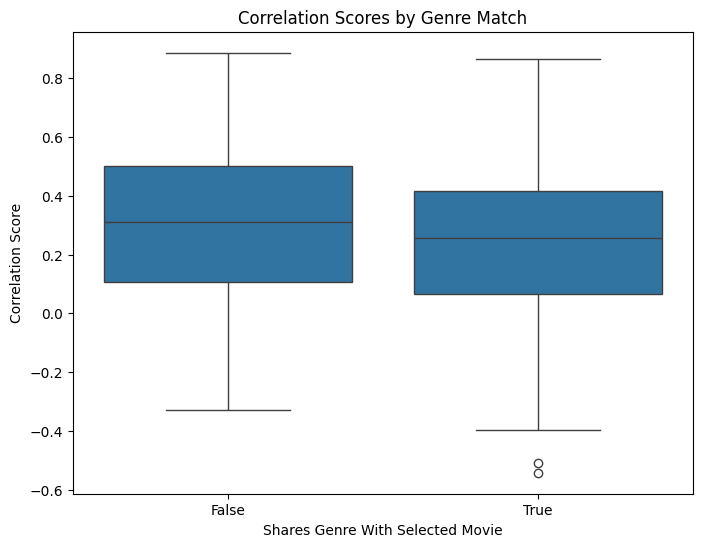

In [24]:
selected_genres = set(
    selected_movie_genre.split("|")
)
item_based_recommendations["genre_match"] = (
    item_based_recommendations["genres"]
    .apply(lambda x: len(selected_genres.intersection(set(x.split("|")))) > 0)
)
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    x="genre_match",
    y="correlation",
    data=item_based_recommendations
)

plt.xlabel("Shares Genre With Selected Movie")
plt.ylabel("Correlation Score")
plt.title("Correlation Scores by Genre Match")

plt.show()

In [25]:
# The boxplot confirms my suspicion that the correlation filter will lead to recommendations that aren't similar in genre at all, with
# the correlation score for movies on the false side having a higher median correlation score than the movies on the true side.
# Method 2B: Hybrid Collaborative Filtering
# In order to even start this method, we first have to grab the genres of each film and use cosine similarity to create similarity scores.

In [26]:
genre_vectors = movies["genres"].str.get_dummies(sep="|")

genre_vectors.head()

from sklearn.metrics.pairwise import cosine_similarity

selected_movie = "28 Days Later (2002)"

selected_index = movies[movies["title"] == selected_movie].index[0]

genre_similarity_scores = cosine_similarity(
    [genre_vectors.loc[selected_index]],
    genre_vectors
)[0]

genre_similarity_df = pd.DataFrame({
    "title": movies["title"],
    "genre_similarity": genre_similarity_scores
})

hybrid_recommendations = item_based_recommendations.merge(
    genre_similarity_df,
    on="title"
)

hybrid_recommendations["hybrid_score"] = (
    0.7 * hybrid_recommendations["correlation"] +
    0.3 * hybrid_recommendations["genre_similarity"]
)

hybrid_recommendations = hybrid_recommendations.sort_values(
    by="hybrid_score",
    ascending=False
)

print(
    hybrid_recommendations[
        ["title", "genres", "correlation", "genre_similarity", "hybrid_score", "rating_count"]
    ].head(10).to_string(index=False)
)

                                 title                           genres  correlation  genre_similarity  hybrid_score  rating_count
Star Trek II: The Wrath of Khan (1982) Action|Adventure|Sci-Fi|Thriller     0.864964          0.577350      0.778680            62
                      Star Trek (2009)     Action|Adventure|Sci-Fi|IMAX     0.761776          0.577350      0.706448            59
            In the Line of Fire (1993)                  Action|Thriller     0.810643          0.408248      0.689925            70
                     Zombieland (2009)             Action|Comedy|Horror     0.631143          0.666667      0.641800            53
       Clear and Present Danger (1994)      Action|Crime|Drama|Thriller     0.765421          0.288675      0.622397           110
            Slumdog Millionaire (2008)              Crime|Drama|Romance     0.886988          0.000000      0.620891            71
                       Maverick (1994)         Adventure|Comedy|Western     0.88286

In [27]:
# Viewing this I see there is still some genres that aren't similar at all sneaking in there, I would much rather have a more strict filter so I will
# create a threshold for the genre similarity to ensure the recommended movies are more closely related in genre to the selected movie.

In [28]:
hybrid_recommendations = hybrid_recommendations[
    hybrid_recommendations["genre_similarity"] >= 0.3
]
print("Selected Movie:", selected_movie)
print("Genre:", selected_movie_genre)
print(
    hybrid_recommendations[
        ["title", "genres", "correlation", "genre_similarity", "hybrid_score", "rating_count"]
         ]
    .rename(columns={
        "genre_similarity": "genre similarity",
        "hybrid_score": "hybrid score",
        "rating_count": "user rating count"
    })
    .head(10).to_string(index=False)
)

Selected Movie: 28 Days Later (2002)
Genre: Action|Horror|Sci-Fi
                                 title                           genres  correlation  genre similarity  hybrid score  user rating count
Star Trek II: The Wrath of Khan (1982) Action|Adventure|Sci-Fi|Thriller     0.864964          0.577350      0.778680                 62
                      Star Trek (2009)     Action|Adventure|Sci-Fi|IMAX     0.761776          0.577350      0.706448                 59
            In the Line of Fire (1993)                  Action|Thriller     0.810643          0.408248      0.689925                 70
                     Zombieland (2009)             Action|Comedy|Horror     0.631143          0.666667      0.641800                 53
                     District 9 (2009)          Mystery|Sci-Fi|Thriller     0.735111          0.333333      0.614578                 65
                   First Knight (1995)             Action|Drama|Romance     0.719636          0.333333      0.603745   

In [29]:
# These results make sense to me, considering the film 28 Days Later is basically a zombie film, and many of the top recommendations are other action and Sci-Fi films
# To further prove why the hybrid filter is better, I will create a scatter plot to show why genre similarity and correlation are both important, and how
# the hybrid filter uses the 0.7 correlation and 0.3 genre similarity to ensure the recommended movies are similar in both aspects, and how the correlation
# filter alone can lead to recommendations that aren't similar in genre at all.

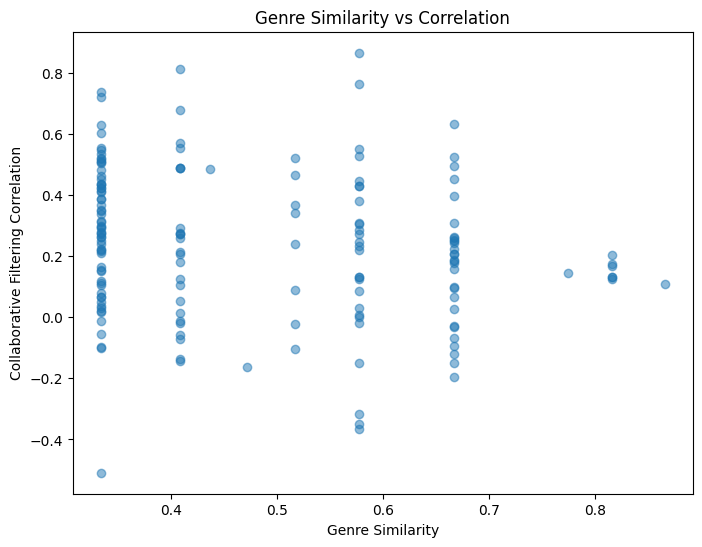

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    hybrid_recommendations["genre_similarity"],
    hybrid_recommendations["correlation"],
    alpha=0.5
)

plt.xlabel("Genre Similarity")
plt.ylabel("Collaborative Filtering Correlation")
plt.title("Genre Similarity vs Correlation")

plt.show()

In [31]:
# Genre similarity is shown in vertical clusters because there is a discrete number of genre combinations, and the collaborative filtering is more varying because
# it's based upon user behavior.
# Further elaborating on my choice of 0.7 for correlation and 0.3 for genre similarity, the recommendations are first based upon user ratings similarities, and the
# genre similarity is a supplementary tool that ensures the movies share at least some genre overlap. My threshold of 0.3 for genre similarity is shown to be useful
# by the scatter plot, as it filters out many movies with a low genre similarity, but high correlation.

In [32]:
# Final Comparison and Conclusion

# Method 1: Popularity-based — This is a good baseline for recommendations, showing the most popular films, however, is not personalized.
# Method 2A: Item-based CF — This is a good first step in personalization of recommendations, but can recommend different genres of films based on random user behavior.
# Method 2B: Hybrid — Works well at balancing user behavior and genre similarity, ensuring that the films recommended are similar to a film the user has watched.

# In conclusion, with my findings, I believe the hybrid method is the best method for film recommendations, as it generally narrows down the recommendations to
# films that are both commonly rated by other users, are popular, and share similar genres, ensuring the recommendations are relevant to the user's tastes. 
# As shown through my analysis, the popularity filter is a good baseline, as it recommends films that are generally well-known and well-liked, but lacks the
# personalization many would want. As shown with my item-based collaborative filtering method, it can recommend films that are popular among users that 
# enjoyed the selected film, but could recommend films that share no genres in common with the selected movie, meaning it wasn't personalized enough.
# Finally, as shown with the hybrid method, balancing the correlation filter with a genre similarity filter ensured that recommended movies are correlated with
# the selected film, share a similar genre, and are popular enough with good ratings to be considered a good recommendations, therefore making it the best method of
# the three for film recommendations.